# Problem 1: SCE-UA

To my understanding, the SCE-UA algorithm is designed specifically to deal with unique problems occuring in conceptual rainfall-runoff (CRR) models. These unique probloems being the frequency of local extrema/bumpiness of the error surface, multiple scales of the local extrema, and flat regions. Derivative based methods like Newton's Method have trouble finding the global minimum due to the rough derivative surfaces with discontinuities. Simplex methods also get trapped in local minima, even when given many starting points. 

These problems with the error surfaces of CRRs created the need for a globally convergent but computationally efficient optimization algorithm that does not rely on smooth derivatives and can avoid getting trapped in the countless small local minima scattered throughout the parameter space. To my understanding, the main idea behind SCE is to treat optimization like an evolutionary process. Instead of starting from one point and descending downhill (like gradient descent), it begins by randomly sampling a large population of parameter sets across the feasible space. These points are evaluated and ranked based on their objective function value. The population is then divided into several smaller groups called complexes. Each complex evolves independently using a simplex-type procedure (reflection, contraction, etc.) to locally improve the worst points.

The main difference that makes SCE-UA ideal for CRRs is the shuffling step. After each complex evolves for a while, all complexes are merged back together, re-ranked globally, and then repdistributed into new complexes. This allows information sharing across the entire population and prevents individual complexes from converging on local minima. The process repeats until convergence.

Compared to other optimization methods, SCE-UA feels like a middle ground between global and local searches. Gradient-based methods are fast but basically useless on the bumpy/discontinuous CRR error surfaces because they just get trapped in one of the many local minima. Genetic algorithms explore globally, but they can be inefficient and sometimes converge too slowly or prematurely. SCE-UA keeps the global exploration through multiple complexes, but also uses directed simplex-style updates.

# Problem 2: Regression for Streamflow Prediction

1. Load the data into a pandas DataFrame and perform any necessary preprocessing (e.g., handling missing values, feature scaling). Consider a sample as a 90 day history of temperature and precipitation data, and the target variable as the streamflow on the 91st day.
2. Split the data into training and testing sets (e.g., 80% training, 20% testing) to evaluate the performance of your regression model. 
3. Train a linear regression model on the training data and evaluate its performance on the testing data using appropriate metrics (e.g., R-squared, mean absolute error). Use a sample size where inputs are the previous 90 days of temperature and precipitation data, and the target variable is the streamflow on the 91st day. You may need to reshape your data accordingly to fit this format.



In [31]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Load from path into pandas df
path = r"C:\Users\jackf\Python Files\HWRS 640\computational_methods_course\data\LeafRiverDaily.csv"
df = pd.read_csv(path)

# keep only temp, precip, sf then coerce numeric and fill missing 
cols = ["Temperature", "Precipitation", "Streamflow"]
df = df[cols].apply(pd.to_numeric, errors="coerce").ffill().bfill()

# Build supervised samples where:
# X = previous 90 days of [Temp, Precip]
# y = Streamflow on day 91
window = 90
X, y = [], []

for i in range(window, len(df)):
    hist = df.loc[i-window:i-1, ["Temperature", "Precipitation"]].values  # (90,2)
    X.append(hist.flatten())  # -> (180,)
    y.append(df.loc[i, "Streamflow"])

X = np.array(X)
y = np.array(y)

# 2) Training and test data split (80/20), no shuffle for time order
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 3) Linear regression + evaluation
model = Pipeline([
    ("scaler", StandardScaler()),   # feature scaling
    ("lr", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"R^2:  {r2:.4f}")
print(f"MAE:  {mae:.6f}")


Train samples: 8696, Test samples: 2174
R^2:  0.6949
MAE:  0.930590


The linear regression model actually did pretty well. An R^2 of about 0.69 means it explains roughly 70% of the variability in next-day streamflow using just the previous 90 days of temperature and precipitation, which is honestly pretty solid for such a simple model. Especially when realizing the nonlinearity between precipitation and basin response. The MAE of about 0.93 shows the average prediction error is under one streamflow unit, which seems reasonable depending on the typical magnitude of flow. Since this is a purely linear model, it can’t capture nonlinear runoff behavior or threshold effects, so there’s probably a natural ceiling to how well it can perform. Overall, it’s pretty awesome given the simplicity of the setup.

Now let's plot it up...

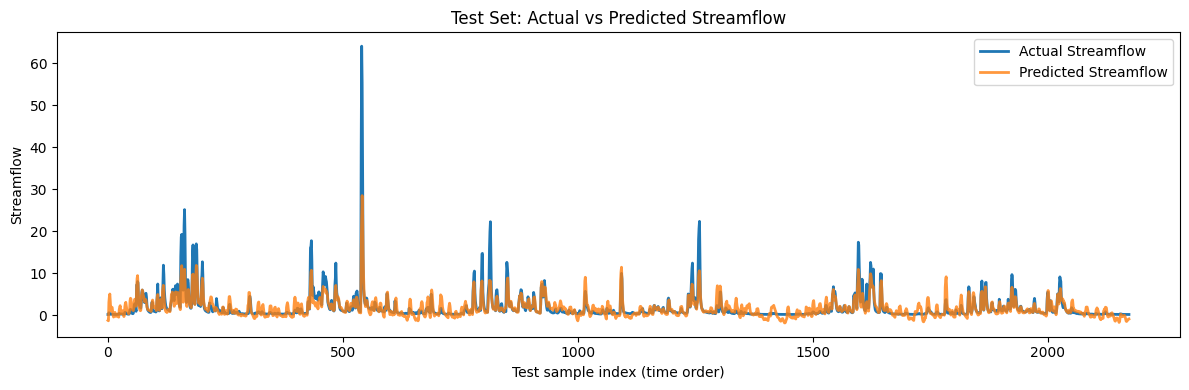

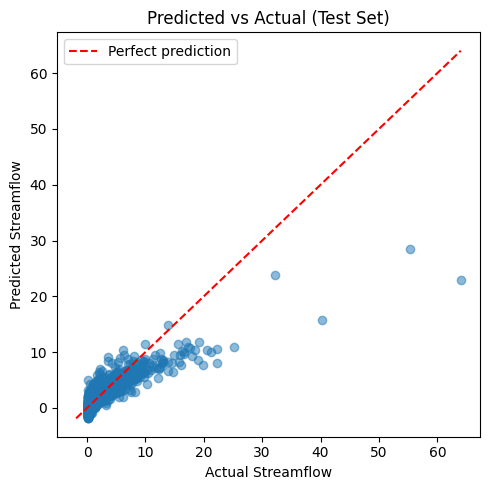

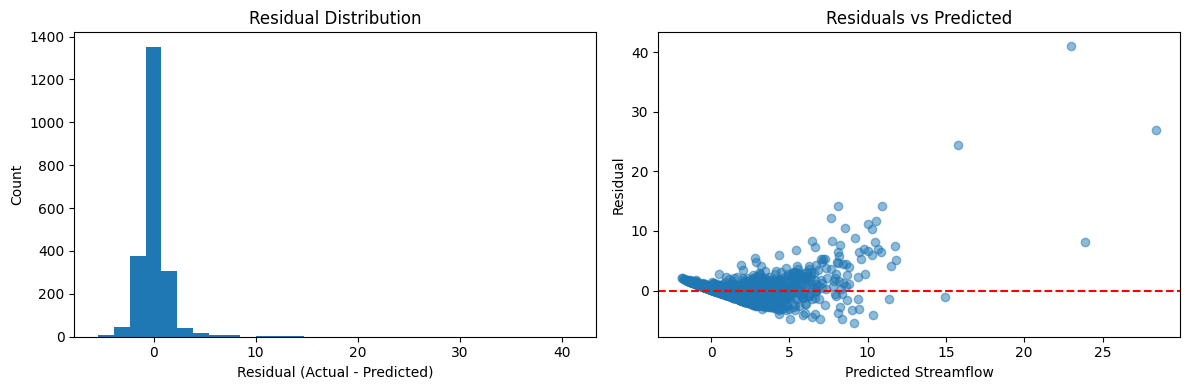

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Actual vs Predicted over test period 
plt.figure(figsize=(12, 4))
plt.plot(y_test, label="Actual Streamflow", linewidth=2)
plt.plot(y_pred, label="Predicted Streamflow", linewidth=2, alpha=0.8)
plt.title("Test Set: Actual vs Predicted Streamflow")
plt.xlabel("Test sample index (time order)")
plt.ylabel("Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Predicted vs Actual scatter
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect prediction")
plt.title("Predicted vs Actual (Test Set)")
plt.xlabel("Actual Streamflow")
plt.ylabel("Predicted Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Residuals 
residuals = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Streamflow")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()


From the plots too, the model is doing a pretty decent job. It tracks the general ups and downs of streamflow pretty well, especially during low to moderate flow periods. You can see in the time series that it follows the overall pattern, but it definitely struggles with the big peak events, tending to underestimate those larger floods.

The predicted vs. actual scatter shows the same thing. Most of the lower flow points sit fairly close to the 1:1 line, but once flows get large, the model falls short. The residual histogram being centered around zero is good, though you can see a few bigger positive errors, which again points to those missed peaks. And the residuals spreading out more at higher flows further shows that error increases with magnitude.

# Problem 3: Calibration of a Simple Hydrologic Model

For this problem you will implement and calibrate a nonlinear hydrological model using the SCE optimization algorithm. The model is a conceptual bucket model expressed as a state-space ODE. The single state variable $S(t)$ represents the water storage in the catchment, and its evolution is governed by:

$$
\frac{dS}{dt} = P(t) - a \cdot \max(T(t),\, 0) - b \cdot S(t)^c
$$

Where:
- $S(t)$ is the catchment storage at time $t$ (the state variable).
- $P(t)$ is the precipitation at time $t$ (a forcing input).
- $T(t)$ is the temperature at time $t$ (a forcing input).
- $a \cdot \max(T(t),\, 0)$ represents evapotranspiration, assumed proportional to temperature when temperature is positive.
- $b \cdot S(t)^c$ is a nonlinear storage-discharge relationship that produces streamflow.

The predicted streamflow is then given by the output equation:

$$
Q(t) = b \cdot S(t)^c
$$

The parameters to calibrate are:
- $a$ — evapotranspiration coefficient
- $b$ — discharge coefficient
- $c$ — nonlinearity exponent of the storage-discharge relationship

Perform the following steps:
1. Implement the model using scipy's `solve_ivp` (or `odeint`) function. You will need to define a function that computes $dS/dt$ given the current state $S$ and the forcing inputs $P(t)$ and $T(t)$. Since the forcing data is daily, you will need to interpolate $P$ and $T$ to evaluate them at arbitrary times requested by the ODE solver. You can use `scipy.interpolate.interp1d` for this purpose.
2. Define an objective function that computes the mean squared error between the observed streamflow and the model-predicted streamflow $Q(t)$ for a given set of parameters.
3. Use the SCE optimization algorithm to find the optimal parameters $a$, $b$, and $c$ that minimize the objective function using the SCE-UA algorithm as implemented with the `spotpy` library.

Note: you should use the spotpy documentation to help you implement the calibration: https://spotpy.readthedocs.io/en/latest/Calibration_with_SCE-UA/

Let's first define our bucket model and run it in time with df inputs of temperature and precipitation and fitted params (a, b, and c) at a value of one...

In [33]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

def run_bucket_model(t_days, P, T, a, b, c, S0=0.0):
    """
    t_days: array of times in days (e.g., 0..N-1)
    P, T  : daily arrays same length as t_days
    a,b,c : parameters
    S0    : initial storage
    returns: S(t), Q(t) evaluated at the daily times
    """

    # 1) Interpolate forcing so solver can query at any time
    P_of_t = interp1d(t_days, P, kind="linear", fill_value="extrapolate")
    T_of_t = interp1d(t_days, T, kind="linear", fill_value="extrapolate")

    # 2) Define the ODE
    def dSdt(t, S):
        S = max(S[0], 0.0)            
        Pt = float(P_of_t(t))
        Tt = float(T_of_t(t))
        ET = a * max(Tt, 0.0)
        Q  = b * (S ** c)
        return [Pt - ET - Q]

    # 3) Solve ODE, evaluate at daily times
    sol = solve_ivp(
        dSdt,
        t_span=(t_days[0], t_days[-1]),
        y0=[S0],
        t_eval=t_days,
        method="RK45"
    )

    S = sol.y[0]
    S = np.maximum(S, 0.0)
    Q = b * (S ** c)
    return S, Q

path = r"C:\Users\jackf\Python Files\HWRS 640\computational_methods_course\data\LeafRiverDaily.csv"
df = pd.read_csv(path)

P = df["Precipitation"].to_numpy(float)
T = df["Temperature"].to_numpy(float)
t_days = np.arange(len(P), dtype=float)

a, b, c = 1, 1, 1
S_model, Q_model = run_bucket_model(t_days, P, T, a, b, c)

Now lets plot it up with the observed data and compute some modeling metrics...

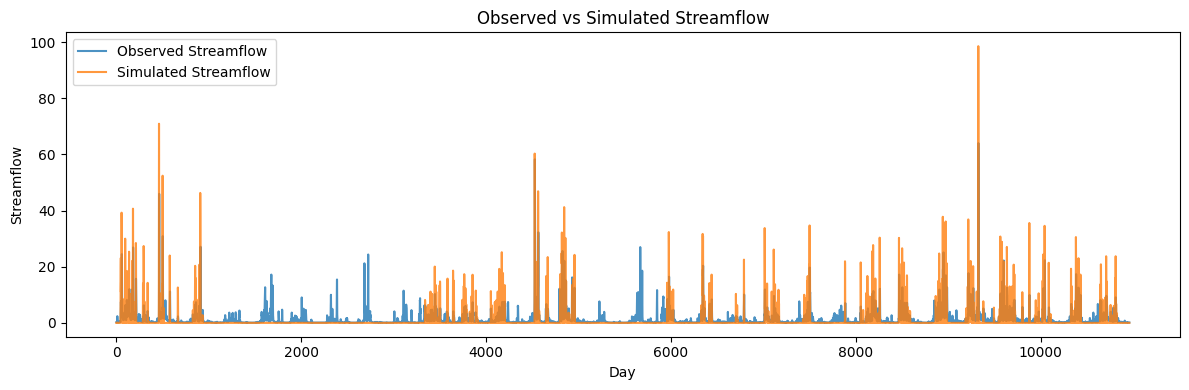

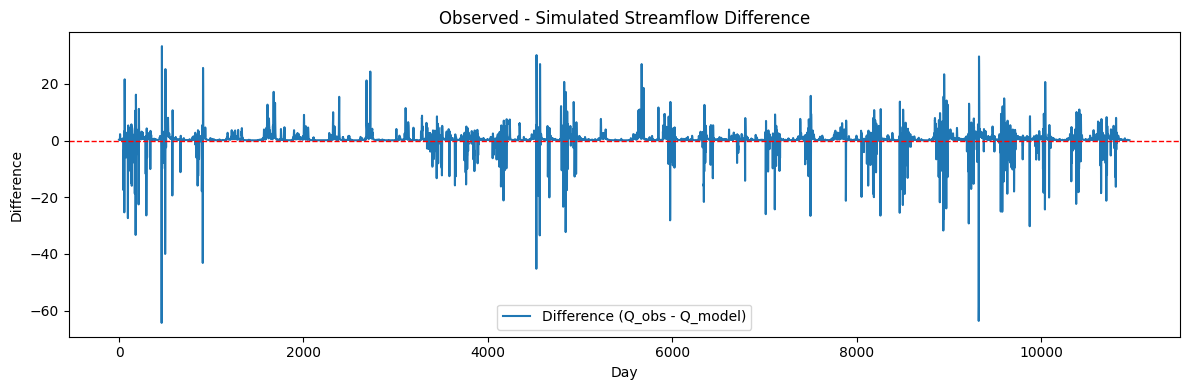

Mean difference: 0.418343
MAE:  1.440256
MSE:  12.683233
RMSE: 3.561353


In [34]:
import matplotlib.pyplot as plt

Q_obs = df["Streamflow"].to_numpy(float)


plt.figure(figsize=(12, 4))
plt.plot(t_days, Q_obs, label="Observed Streamflow", alpha=0.8)
plt.plot(t_days, Q_model, label="Simulated Streamflow", alpha=0.8)
plt.xlabel("Day")
plt.ylabel("Streamflow")
plt.title("Observed vs Simulated Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

# Difference (residual): observed - simulated
diff = Q_obs - Q_model

# plot the difference over time
plt.figure(figsize=(12,4))
plt.plot(t_days, diff, label="Difference (Q_obs - Q_model)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Day")
plt.ylabel("Difference")
plt.title("Observed - Simulated Streamflow Difference")
plt.legend()
plt.tight_layout()
plt.show()

# summary stats
mae = np.mean(np.abs(diff))
mse = np.mean(diff**2)
rmse = np.sqrt(mse)
bias = np.mean(diff)

print(f"Mean difference: {bias:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")


So with a=b=c=1, we’re just letting the bucket run with no real calibration, just a raw first pass. You can see pretty quickly that it’s not matching the observed streamflow very well. The simulated peaks are often way too large and don’t line up cleanly with the observed ones.

Now let's get onto calibrating these parameter values. First, we're going to need an objective function...

Define the objective function as:

$$
J(a,b,c,S_0)=\frac{1}{N}\sum_{t=1}^{N}\left(Q_{\text{obs}}(t)-Q_{\text{model}}(t; a,b,c,S_0)\right)^2
$$

Where:
- $Q_{\text{obs}}(t)$ is observed streamflow at day $t$,
- $Q_{\text{model}}(t; a,b,c)$ is model-predicted streamflow using parameters $a,b,c$,
- $N$ is the number of time steps.

Calibration goal: find $a,b,c$ that minimize $J(a,b,c)$.


Let's first define our training...

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spotpy

# assumes these already exist in your notebook:
# df, window, split_idx, run_bucket_model

train_start = window
train_end = window + split_idx
test_start = train_end
test_end = len(df)

t_all = np.arange(len(df), dtype=float)
P_all = df["Precipitation"].to_numpy(float)
T_all = df["Temperature"].to_numpy(float)
Q_all = df["Streamflow"].to_numpy(float)

t_train = t_all[train_start:train_end]
P_train = P_all[train_start:train_end]
T_train = T_all[train_start:train_end]
Q_train = Q_all[train_start:train_end]

t_test = t_all[test_start:test_end]
P_test = P_all[test_start:test_end]
T_test = T_all[test_start:test_end]
Q_test = Q_all[test_start:test_end]

class SpotSetup:
    def parameters(self):
        return spotpy.parameter.generate([
            spotpy.parameter.Uniform("a", 0.0, 1),
            spotpy.parameter.Uniform("b", 0.001, 2.0),
            spotpy.parameter.Uniform("c", 0.5, 3.0),
            spotpy.parameter.Uniform("S0", 1.0, 100.0),
        ])

    def simulation(self, p):
        a, b, c, S0 = p
        _, q = run_bucket_model(t_train, P_train, T_train, a, b, c, S0=S0)
        return q

    def evaluation(self):
        return Q_train

    def objectivefunction(self, simulation, evaluation):
        return np.mean((np.asarray(evaluation) - np.asarray(simulation))**2)  # MSE


now run and save it...

In [36]:
RESULTS_FILE = "sceua_results.npy"
BEST_FILE = "sceua_best_params.npz"

if os.path.exists(RESULTS_FILE) and os.path.exists(BEST_FILE):
    print("Training already exists. Skipping sampler.sample(...).")
else:
    setup = SpotSetup()
    sampler = spotpy.algorithms.sceua(setup, dbname="bucket_sceua", dbformat="ram")
    sampler.sample(15000, ngs=7, kstop=3, peps=0.1, pcento=0.1)

    results = sampler.getdata()
    np.save(RESULTS_FILE, results)

    best_idx = np.argmin(results["like1"])
    best = results[best_idx]

    def get_param(row, name):
        for k in [f"para_{name}", f"par{name}", f"para{name}"]:
            if k in row.dtype.names:
                return float(row[k])
        raise KeyError(f"Missing parameter '{name}'. Available: {row.dtype.names}")

    best_a = get_param(best, "a")
    best_b = get_param(best, "b")
    best_c = get_param(best, "c")
    best_S0 = get_param(best, "S0")
    train_mse = float(best["like1"])

    np.savez(BEST_FILE, a=best_a, b=best_b, c=best_c, S0=best_S0, train_mse=train_mse)
    print("Training complete and saved.")


Training already exists. Skipping sampler.sample(...).


Grab data and print metrics... 

=== SCE-UA Best Fit ===
a: 0.840594
b: 0.155635
c: 0.974421
S0: 34.139743
MSE : 4.294382
RMSE: 2.072289
KGE   : 0.7163
r     : 0.8071
alpha : 0.9080
beta  : 1.1867


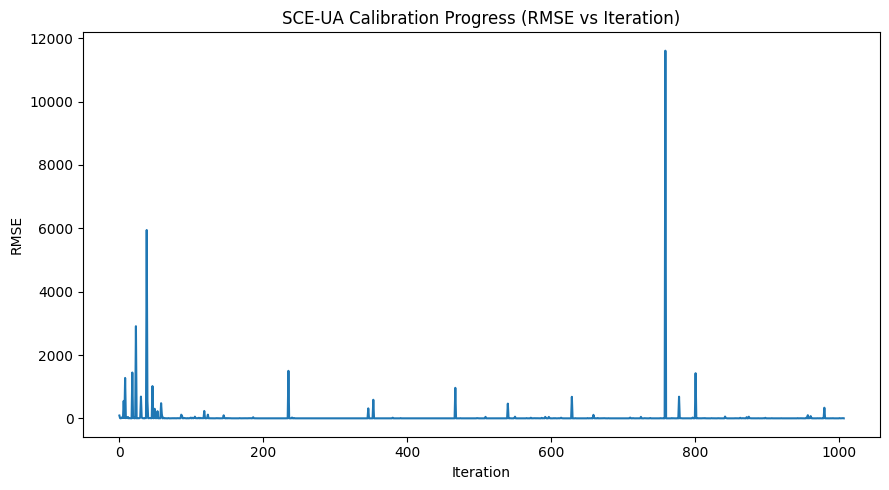

In [41]:
results = np.load("sceua_results.npy", allow_pickle=True)
best_data = np.load("sceua_best_params.npz")

best_a = float(best_data["a"])
best_b = float(best_data["b"])
best_c = float(best_data["c"])
train_mse = float(best_data["train_mse"])

_, q_test_sim = run_bucket_model(t_test, P_test, T_test, best_a, best_b, best_c, S0=1.0)
test_mse = np.mean((Q_test - q_test_sim)**2)
test_rmse = np.sqrt(test_mse)

import numpy as np

def kling_gupta_efficiency(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)

    # remove NaNs/infs if any
    m = np.isfinite(obs) & np.isfinite(sim)
    obs = obs[m]
    sim = sim[m]

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim, ddof=1) / np.std(obs, ddof=1)
    beta = np.mean(sim) / np.mean(obs)

    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge, r, alpha, beta

# example with your test set
kge, r, alpha, beta = kling_gupta_efficiency(Q_test, q_test_sim)

print("=== SCE-UA Best Fit ===")
print(f"a: {best_a:.6f}")
print(f"b: {best_b:.6f}")
print(f"c: {best_c:.6f}")
print(f"S0: {best_S0:.6f}")
print(f"MSE : {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"KGE   : {kge:.4f}")
print(f"r     : {r:.4f}")
print(f"alpha : {alpha:.4f}")
print(f"beta  : {beta:.4f}")

rmse_iter = np.sqrt(results["like1"])

plt.figure(figsize=(9,5))
plt.plot(rmse_iter, lw=1.5)
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("SCE-UA Calibration Progress (RMSE vs Iteration)")
plt.tight_layout()
plt.show()



After running SCE-UA, we ended up with a much more reasonable set of bucket-model parameters rather than just setting them all equal to one. Oddly enough, I got a KGE of ~ -0.5 before calibrating the initial conditions, but ended up with a much better KGE of 0.72 after.

And that RMSE-vs-iteration plot is basically showing SCE doing what it’s supposed to do: it explores some terrible parameter combos early on (big RMSE spikes), then settles into a lower-error region once it starts homing in on the good parameter space.

# Problem 4: Comparison of Linear Regression vs. SCE Optimization

Compare the performance of the linear regression model and the SCE optimization algorithm for predicting streamflow from the previous problems based on the same dataset. Perform the following steps:

1. Calculate the Overall NSE (Nash-Sutcliffe Efficiency) for both models on the testing data. The NSE is defined as:
$$
NSE = 1 - \frac{\sum_{i=1}^{n} (Q_{obs,i} - Q_{pred,i})^2}{\sum_{i=1}^{n} (Q_{obs,i} - \bar{Q}_{obs})^2}
$$
Where $Q_{obs,i}$ is the observed streamflow, $Q_{pred,i}$ is the predicted streamflow, and $\bar{Q}_{obs}$ is the mean of the observed streamflow.
2. Create a figure that compares the observed streamflow with the predictions from both models over time. Include appropriate labels, legends, and titles to clearly distinguish between the observed data and the predictions from the linear regression and SCE models.
3. Discuss the results: Which model performs better in terms of NSE? What are the strengths and weaknesses of each model? How might you improve the performance of each model? 


NSE (Linear Regression): 0.6949
NSE (SCE Bucket Model):  0.6314


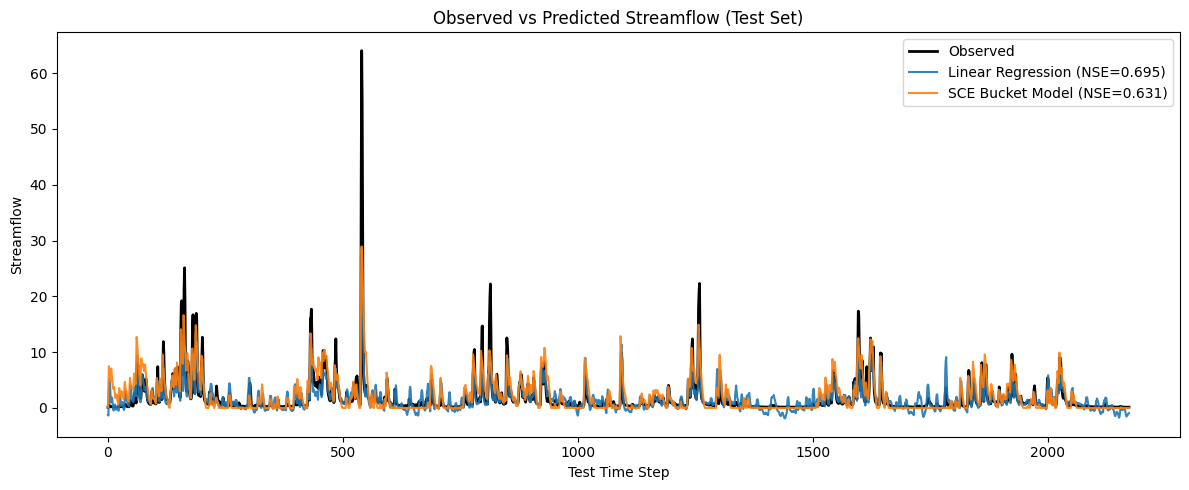

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - sim)**2) / denom

# Use common aligned test length
n = min(len(y_pred), len(q_test_sim), len(Q_test))
obs = np.asarray(Q_test[:n], dtype=float)       # observed streamflow
pred_lr = np.asarray(y_pred[:n], dtype=float)   # linear regression
pred_sce = np.asarray(q_test_sim[:n], dtype=float)  # SCE/bucket model

nse_lr = nse(obs, pred_lr)
nse_sce = nse(obs, pred_sce)

print(f"NSE (Linear Regression): {nse_lr:.4f}")
print(f"NSE (SCE Bucket Model):  {nse_sce:.4f}")


plt.figure(figsize=(12,5))
plt.plot(obs, label="Observed", color="black", linewidth=2)
plt.plot(pred_lr, label=f"Linear Regression (NSE={nse_lr:.3f})", alpha=0.9)
plt.plot(pred_sce, label=f"SCE Bucket Model (NSE={nse_sce:.3f})", alpha=0.9)
plt.xlabel("Test Time Step")
plt.ylabel("Streamflow")
plt.title("Observed vs Predicted Streamflow (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression metrics
lr_mae  = mean_absolute_error(obs, pred_lr)
lr_mse  = mean_squared_error(obs, pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2   = r2_score(obs, pred_lr)
lr_nse  = nse(obs, pred_lr)
lr_kge, lr_r, lr_alpha, lr_beta = kling_gupta_efficiency(obs, pred_lr)
lr_l2   = np.linalg.norm(obs - pred_lr, ord=2)

# Bucket/SCE metrics
sce_mae  = mean_absolute_error(obs, pred_sce)
sce_mse  = mean_squared_error(obs, pred_sce)
sce_rmse = np.sqrt(sce_mse)
sce_r2   = r2_score(obs, pred_sce)
sce_nse  = nse(obs, pred_sce)
sce_kge, sce_r, sce_alpha, sce_beta = kling_gupta_efficiency(obs, pred_sce)
sce_l2   = np.linalg.norm(obs - pred_sce, ord=2)

metrics_table = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": lr_mae, "MSE": lr_mse, "RMSE": lr_rmse, "R2": lr_r2,
        "NSE": lr_nse, "KGE": lr_kge, "r": lr_r, "alpha": lr_alpha, "beta": lr_beta,
        "L2_norm": lr_l2
    },
    {
        "Model": "Bucket Model (SCE-UA)",
        "MAE": sce_mae, "MSE": sce_mse, "RMSE": sce_rmse, "R2": sce_r2,
        "NSE": sce_nse, "KGE": sce_kge, "r": sce_r, "alpha": sce_alpha, "beta": sce_beta,
        "L2_norm": sce_l2
    }
]).round(4)

display(metrics_table)


,Model,MAE,MSE,RMSE,R2,NSE,KGE,r,alpha,beta,L2_norm
0,Linear Regression,0.9306,3.5546,1.8854,0.6949,0.6949,0.6334,0.8546,0.6692,0.9382,87.9073
1,Bucket Model (SCE-UA),1.1704,4.2944,2.0723,0.6314,0.6314,0.7163,0.8071,0.9080,1.1867,96.6229


With the updated metrics, the linear regression still comes out ahead in terms of raw predictive accuracy. It has lower MAE and RMSE and a higher NSE (~0.695 vs ~0.631), so if we’re just trying to minimize squared error on the test set, the linear model performs better.

That said, the bucket model actually holds its own pretty well. Its KGE is higher (~0.72 vs ~0.63), and its variability ratio is much closer to 1, meaning it does a better job reproducing the overall spread and dynamics of the flows. The tradeoff is that it has more bias (beta > 1), so it tends to overpredict on average.

So basically, the linear regression is the stronger target predictor here, but the SCE-calibrated bucket model is more physically meaningful and does a better job representing hydrologic behavior.

For the bucket model, I’d improve it by making it a little less “one simple tank fits all.” Add a warm-up period and a better initial storage guess, put realistic bounds on a,b,c, and calibrate using something like KGE or an NSE so it doesn’t only chase peaks. Structurally, the biggest upgrade would be adding one more reservoir or splitting flow into stormflow and baseflow, and maybe adding a simple storage capacity/threshold so runoff kicks in more realistically.